In [2]:
import pandas as pd
df = pd.read_csv(r"C:\Akshy\to do eda\IPL (1).csv")
print(df.columns.tolist())
print(df.shape)
print(df.head(2))

C:\Users\Prince\AppData\Local\Temp\ipykernel_21660\2134467138.py:2: DtypeWarning: Columns (28,29,30,31,43,46,47,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Akshy\to do eda\IPL (1).csv")


['Unnamed: 0', 'match_id', 'date', 'match_type', 'event_name', 'innings', 'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter', 'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball', 'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary', 'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind', 'player_out', 'fielders', 'runs_target', 'review_batter', 'team_reviewed', 'review_decision', 'umpire', 'umpires_call', 'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner', 'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season', 'gender', 'team_type', 'superover_winner', 'result_type', 'method', 'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number', 'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'power_surge_start', 'batter_runs', 'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter', 'striker_out']
(283678, 65)
   Unnamed: 0  match_id        date match_type             event_name  \
0      14160

In [3]:
df.columns.tolist()

['Unnamed: 0',
 'match_id',
 'date',
 'match_type',
 'event_name',
 'innings',
 'batting_team',
 'bowling_team',
 'over',
 'ball',
 'ball_no',
 'batter',
 'bat_pos',
 'runs_batter',
 'balls_faced',
 'bowler',
 'valid_ball',
 'runs_extras',
 'runs_total',
 'runs_bowler',
 'runs_not_boundary',
 'extra_type',
 'non_striker',
 'non_striker_pos',
 'wicket_kind',
 'player_out',
 'fielders',
 'runs_target',
 'review_batter',
 'team_reviewed',
 'review_decision',
 'umpire',
 'umpires_call',
 'player_of_match',
 'match_won_by',
 'win_outcome',
 'toss_winner',
 'toss_decision',
 'venue',
 'city',
 'day',
 'month',
 'year',
 'season',
 'gender',
 'team_type',
 'superover_winner',
 'result_type',
 'method',
 'balls_per_over',
 'overs',
 'event_match_no',
 'stage',
 'match_number',
 'team_runs',
 'team_balls',
 'team_wicket',
 'new_batter',
 'power_surge_start',
 'batter_runs',
 'batter_balls',
 'bowler_wicket',
 'batting_partners',
 'next_batter',
 'striker_out']

In [4]:
cols_to_keep = [
    # match info
    'match_id', 'date', 'season', 'stage', 'venue',
    # teams & toss
    'batting_team', 'bowling_team',
    'toss_winner', 'toss_decision', 'win_outcome',
    # ball-by-ball
    'innings', 'over', 'ball',
    'batter', 'bowler',
    'runs_batter', 'runs_total',
    # wickets
    'wicket_kind', 'player_out',
    # result
    'player_of_match', 'match_won_by', 'result_type'
]

df = df[cols_to_keep]
print(df.shape)   # should show (rows, 22)
print(df.isnull().sum())

(283678, 22)
match_id                0
date                    0
season                  0
stage                   0
venue                   0
batting_team            0
bowling_team            0
toss_winner             0
toss_decision           0
win_outcome          4724
innings                 0
over                    0
ball                    0
batter                  0
bowler                  0
runs_batter             0
runs_total              0
wicket_kind        269572
player_out         269572
player_of_match         0
match_won_by            0
result_type        278954
dtype: int64


In [5]:
df['wicket_kind'] = df['wicket_kind'].fillna('no_wicket') #filling null values with 'no_wicket' for better analysis
print(df['wicket_kind'].value_counts())

wicket_kind
no_wicket                269572
caught                     8880
bowled                     2379
run out                    1169
lbw                         861
caught and bowled           394
stumped                     378
retired hurt                 18
hit wicket                   18
retired out                   6
obstructing the field         3
Name: count, dtype: int64


In [6]:
df['player_out'] = df['player_out'].fillna('not_out') #filling null values with 'not_out' for better analysis
print(df['player_out'].value_counts())

player_out
not_out            269572
RG Sharma             241
V Kohli               223
S Dhawan              193
KD Karthik            184
                    ...  
M de Lange              1
AN Ahmed                1
DJ Muthuswami           1
Karanveer Singh         1
LG Pretorius            1
Name: count, Length: 671, dtype: int64


In [7]:
print(df['result_type'].value_counts())

result_type
tie          3896
no result     828
Name: count, dtype: int64


In [8]:
df['result_type'] = df['result_type'].fillna('normal')
print(df['result_type'].value_counts())

result_type
normal       278954
tie            3896
no result       828
Name: count, dtype: int64


In [9]:
null_matches = df[df['win_outcome'].isna()]['match_id'].nunique()
print(f"Matches with no win_outcome: {null_matches}")

Matches with no win_outcome: 24


In [10]:

# Check result_type for those matches
print(df[df['win_outcome'].isna()]['result_type'].value_counts())

result_type
tie          3896
no result     828
Name: count, dtype: int64


In [11]:
df['win_outcome'] = df['win_outcome'].fillna('no_result')

In [12]:
df['win_outcome'].value_counts()

win_outcome
6 wickets    31503
7 wickets    29010
5 wickets    25190
8 wickets    19623
4 wickets    15059
             ...  
93 runs        219
138 runs       212
146 runs       211
76 runs        204
112 runs       189
Name: count, Length: 112, dtype: int64

In [13]:
df.isnull().sum()

match_id           0
date               0
season             0
stage              0
venue              0
batting_team       0
bowling_team       0
toss_winner        0
toss_decision      0
win_outcome        0
innings            0
over               0
ball               0
batter             0
bowler             0
runs_batter        0
runs_total         0
wicket_kind        0
player_out         0
player_of_match    0
match_won_by       0
result_type        0
dtype: int64

In [14]:
df['date'] = pd.to_datetime(df['date'])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283678 entries, 0 to 283677
Data columns (total 22 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   match_id         283678 non-null  int64         
 1   date             283678 non-null  datetime64[ns]
 2   season           283678 non-null  object        
 3   stage            283678 non-null  object        
 4   venue            283678 non-null  object        
 5   batting_team     283678 non-null  object        
 6   bowling_team     283678 non-null  object        
 7   toss_winner      283678 non-null  object        
 8   toss_decision    283678 non-null  object        
 9   win_outcome      283678 non-null  object        
 10  innings          283678 non-null  int64         
 11  over             283678 non-null  int64         
 12  ball             283678 non-null  int64         
 13  batter           283678 non-null  object        
 14  bowler           283

In [16]:
df.head(20)

,match_id,date,season,stage,venue,batting_team,bowling_team,toss_winner,toss_decision,win_outcome,...,ball,batter,bowler,runs_batter,runs_total,wicket_kind,player_out,player_of_match,match_won_by,result_type
0,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,140 runs,...,1,SC Ganguly,P Kumar,0,1,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
1,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,140 runs,...,2,BB McCullum,P Kumar,0,0,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
2,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,140 runs,...,3,BB McCullum,P Kumar,0,1,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
3,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,140 runs,...,3,BB McCullum,P Kumar,0,0,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
4,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,140 runs,...,4,BB McCullum,P Kumar,0,0,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
5,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,140 runs,...,5,BB McCullum,P Kumar,0,0,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
6,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,140 runs,...,6,BB McCullum,P Kumar,0,1,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
7,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,140 runs,...,1,BB McCullum,Z Khan,0,0,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
8,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,140 runs,...,2,BB McCullum,Z Khan,4,4,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
9,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,140 runs,...,3,BB McCullum,Z Khan,4,4,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal


In [17]:
df.columns.str.title()

Index(['Match_Id', 'Date', 'Season', 'Stage', 'Venue', 'Batting_Team',
       'Bowling_Team', 'Toss_Winner', 'Toss_Decision', 'Win_Outcome',
       'Innings', 'Over', 'Ball', 'Batter', 'Bowler', 'Runs_Batter',
       'Runs_Total', 'Wicket_Kind', 'Player_Out', 'Player_Of_Match',
       'Match_Won_By', 'Result_Type'],
      dtype='object')

In [18]:
df.head(20)

,match_id,date,season,stage,venue,batting_team,bowling_team,toss_winner,toss_decision,win_outcome,...,ball,batter,bowler,runs_batter,runs_total,wicket_kind,player_out,player_of_match,match_won_by,result_type
0,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,140 runs,...,1,SC Ganguly,P Kumar,0,1,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
1,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,140 runs,...,2,BB McCullum,P Kumar,0,0,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
2,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,140 runs,...,3,BB McCullum,P Kumar,0,1,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
3,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,140 runs,...,3,BB McCullum,P Kumar,0,0,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
4,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,140 runs,...,4,BB McCullum,P Kumar,0,0,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
5,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,140 runs,...,5,BB McCullum,P Kumar,0,0,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
6,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,140 runs,...,6,BB McCullum,P Kumar,0,1,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
7,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,140 runs,...,1,BB McCullum,Z Khan,0,0,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
8,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,140 runs,...,2,BB McCullum,Z Khan,4,4,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
9,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,140 runs,...,3,BB McCullum,Z Khan,4,4,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal


In [19]:
team_map = {
    'Delhi Daredevils'           : 'Delhi Capitals',
    'Kings XI Punjab'            : 'Punjab Kings',
    'Deccan Chargers'            : 'Sunrisers Hyderabad',
    'Pune Warriors'              : 'Rising Pune Supergiant',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'
}
df['batting_team'] = df['batting_team'].replace(team_map)
df['bowling_team'] = df['bowling_team'].replace(team_map)
df['toss_winner']  = df['toss_winner'].replace(team_map)
df['win_outcome']  = df['win_outcome'].replace(team_map)
df.head(20)

,match_id,date,season,stage,venue,batting_team,bowling_team,toss_winner,toss_decision,win_outcome,...,ball,batter,bowler,runs_batter,runs_total,wicket_kind,player_out,player_of_match,match_won_by,result_type
0,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bengaluru,Royal Challengers Bengaluru,field,140 runs,...,1,SC Ganguly,P Kumar,0,1,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
1,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bengaluru,Royal Challengers Bengaluru,field,140 runs,...,2,BB McCullum,P Kumar,0,0,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
2,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bengaluru,Royal Challengers Bengaluru,field,140 runs,...,3,BB McCullum,P Kumar,0,1,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
3,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bengaluru,Royal Challengers Bengaluru,field,140 runs,...,3,BB McCullum,P Kumar,0,0,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
4,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bengaluru,Royal Challengers Bengaluru,field,140 runs,...,4,BB McCullum,P Kumar,0,0,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
5,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bengaluru,Royal Challengers Bengaluru,field,140 runs,...,5,BB McCullum,P Kumar,0,0,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
6,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bengaluru,Royal Challengers Bengaluru,field,140 runs,...,6,BB McCullum,P Kumar,0,1,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
7,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bengaluru,Royal Challengers Bengaluru,field,140 runs,...,1,BB McCullum,Z Khan,0,0,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
8,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bengaluru,Royal Challengers Bengaluru,field,140 runs,...,2,BB McCullum,Z Khan,4,4,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
9,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bengaluru,Royal Challengers Bengaluru,field,140 runs,...,3,BB McCullum,Z Khan,4,4,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal


In [20]:
df.columns=[df.columns.str.title()]

In [21]:
df.head(2)

,Match_Id,Date,Season,Stage,Venue,Batting_Team,Bowling_Team,Toss_Winner,Toss_Decision,Win_Outcome,...,Ball,Batter,Bowler,Runs_Batter,Runs_Total,Wicket_Kind,Player_Out,Player_Of_Match,Match_Won_By,Result_Type
0,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bengaluru,Royal Challengers Bengaluru,field,140 runs,...,1,SC Ganguly,P Kumar,0,1,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal
1,335982,2008-04-18,2007/08,Unknown,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bengaluru,Royal Challengers Bengaluru,field,140 runs,...,2,BB McCullum,P Kumar,0,0,no_wicket,not_out,BB McCullum,Kolkata Knight Riders,normal


In [22]:
print(df.isnull().sum())

Match_Id           0
Date               0
Season             0
Stage              0
Venue              0
Batting_Team       0
Bowling_Team       0
Toss_Winner        0
Toss_Decision      0
Win_Outcome        0
Innings            0
Over               0
Ball               0
Batter             0
Bowler             0
Runs_Batter        0
Runs_Total         0
Wicket_Kind        0
Player_Out         0
Player_Of_Match    0
Match_Won_By       0
Result_Type        0
dtype: int64


In [23]:
df.duplicated().sum()

636

In [24]:
# See what the duplicates look like
print(df[df.duplicated()].head(10))

# Check if they're duplicate balls or duplicate match-level info
print(df[df.duplicated()]['Match_Id'].nunique())

     Match_Id       Date   Season    Stage  \
166    335982 2008-04-18  2007/08  Unknown   
180    335982 2008-04-18  2007/08  Unknown   
188    335982 2008-04-18  2007/08  Unknown   
1226   335987 2008-04-21  2007/08  Unknown   
1815   335989 2008-04-23  2007/08  Unknown   
1816   335989 2008-04-23  2007/08  Unknown   
1994   335990 2008-04-24  2007/08  Unknown   
2420   335992 2008-04-26  2007/08  Unknown   
3048   335995 2008-04-27  2007/08  Unknown   
3660   335997 2008-04-29  2007/08  Unknown   

                                           Venue                 Batting_Team  \
166                        M Chinnaswamy Stadium  Royal Challengers Bengaluru   
180                        M Chinnaswamy Stadium  Royal Challengers Bengaluru   
188                        M Chinnaswamy Stadium  Royal Challengers Bengaluru   
1226                      Sawai Mansingh Stadium                 Punjab Kings   
1815             MA Chidambaram Stadium, Chepauk               Mumbai Indians   
1816   

sql lite


In [25]:
import sqlite3
import pandas as pd

In [26]:
conn = sqlite3.connect('ipl_2025.db') # creating  the database ile


In [27]:
df.to_sql('ipl', conn, if_exists='replace', index=False) #writting the all the data created in the df to the database


283678

In [28]:
check = pd.read_sql("SELECT COUNT(*) as total_rows FROM ipl", conn) # checking if the data is written to the database or not
print(check)

   total_rows
0      283678


In [29]:
cols = pd.read_sql("PRAGMA table_info(ipl)", conn) # checking the columns and their data types in the database
print(cols[['name', 'type']]) # checking the columns and their data types in the database

                    name       type
0          ('Match_Id',)    INTEGER
1              ('Date',)  TIMESTAMP
2            ('Season',)       TEXT
3             ('Stage',)       TEXT
4             ('Venue',)       TEXT
5      ('Batting_Team',)       TEXT
6      ('Bowling_Team',)       TEXT
7       ('Toss_Winner',)       TEXT
8     ('Toss_Decision',)       TEXT
9       ('Win_Outcome',)       TEXT
10          ('Innings',)    INTEGER
11             ('Over',)    INTEGER
12             ('Ball',)    INTEGER
13           ('Batter',)       TEXT
14           ('Bowler',)       TEXT
15      ('Runs_Batter',)    INTEGER
16       ('Runs_Total',)    INTEGER
17      ('Wicket_Kind',)       TEXT
18       ('Player_Out',)       TEXT
19  ('Player_Of_Match',)       TEXT
20     ('Match_Won_By',)       TEXT
21      ('Result_Type',)       TEXT


In [30]:
# Flatten MultiIndex columns to single level
df.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in df.columns]

# Now lowercase
df.columns = df.columns.str.lower()

# Verify
print(df.columns.tolist())

['match_id', 'date', 'season', 'stage', 'venue', 'batting_team', 'bowling_team', 'toss_winner', 'toss_decision', 'win_outcome', 'innings', 'over', 'ball', 'batter', 'bowler', 'runs_batter', 'runs_total', 'wicket_kind', 'player_out', 'player_of_match', 'match_won_by', 'result_type']


In [31]:
print(type(df.columns))
print(df.columns)

<class 'pandas.core.indexes.base.Index'>
Index(['match_id', 'date', 'season', 'stage', 'venue', 'batting_team',
       'bowling_team', 'toss_winner', 'toss_decision', 'win_outcome',
       'innings', 'over', 'ball', 'batter', 'bowler', 'runs_batter',
       'runs_total', 'wicket_kind', 'player_out', 'player_of_match',
       'match_won_by', 'result_type'],
      dtype='object')


In [32]:
# Just re-save df to SQLite — this updates the db file with current column names
df.to_sql('ipl', conn, if_exists='replace', index=False)

# Verify it worked
pd.read_sql("SELECT DISTINCT season FROM ipl ORDER BY season", conn)

,season
0,2007/08
1,2009
2,2009/10
3,2011
4,2012
5,2013
6,2014
7,2015
8,2016
9,2017


Most wins by team

In [33]:
q1 = pd.read_sql("""
    SELECT win_outcome AS team,
           COUNT(DISTINCT match_id) AS wins
    FROM ipl
    WHERE win_outcome != 'no_result'
      AND innings = 1
    GROUP BY win_outcome
    ORDER BY wins DESC
""", conn)
q1

,team,wins
0,6 wickets,133
1,7 wickets,124
2,5 wickets,105
3,8 wickets,88
4,4 wickets,62
...,...,...
106,110 runs,1
107,106 runs,1
108,105 runs,1
109,102 runs,1


In [34]:
print(df['match_won_by'].value_counts().head(10))
print("---")
print(df['batting_team'].value_counts().head(10))
print("---")
print(df['toss_winner'].value_counts().head(10))

match_won_by
Mumbai Indians                 36432
Chennai Super Kings            34878
Kolkata Knight Riders          31729
Rajasthan Royals               28295
Royal Challengers Bangalore    26801
Sunrisers Hyderabad            22665
Kings XI Punjab                20162
Delhi Daredevils               15709
Delhi Capitals                 12762
Gujarat Titans                  9491
Name: count, dtype: int64
---
batting_team
Mumbai Indians                 33892
Sunrisers Hyderabad            33112
Royal Challengers Bengaluru    32308
Punjab Kings                   31977
Delhi Capitals                 31886
Kolkata Knight Riders          31398
Chennai Super Kings            31027
Rajasthan Royals               28430
Gujarat Titans                  7827
Lucknow Super Giants            7750
Name: count, dtype: int64
---
toss_winner
Mumbai Indians                 36890
Delhi Capitals                 33569
Sunrisers Hyderabad            32739
Rajasthan Royals               31308
Chennai Super 

In [35]:
for col in df.columns:
    if df[col].dtype == 'object':
        if df[col].str.contains('Mumbai', na=False).any():
            print(f"✓ Column '{col}' contains team names")

✓ Column 'venue' contains team names
✓ Column 'batting_team' contains team names
✓ Column 'bowling_team' contains team names
✓ Column 'toss_winner' contains team names
✓ Column 'match_won_by' contains team names


In [36]:
print(df['match_won_by'].value_counts().head(10))

match_won_by
Mumbai Indians                 36432
Chennai Super Kings            34878
Kolkata Knight Riders          31729
Rajasthan Royals               28295
Royal Challengers Bangalore    26801
Sunrisers Hyderabad            22665
Kings XI Punjab                20162
Delhi Daredevils               15709
Delhi Capitals                 12762
Gujarat Titans                  9491
Name: count, dtype: int64


In [37]:
team_map = {
    'Delhi Daredevils'            : 'Delhi Capitals',
    'Kings XI Punjab'             : 'Punjab Kings',
    'Deccan Chargers'             : 'Sunrisers Hyderabad',
    'Pune Warriors'               : 'Rising Pune Supergiant',
    'Royal Challengers Bangalore' : 'Royal Challengers Bengaluru'
}

df['match_won_by'] = df['match_won_by'].replace(team_map)

# Re-save to SQLite
df.to_sql('ipl', conn, if_exists='replace', index=False)

# Verify fix
print(df['match_won_by'].value_counts().head(10))

match_won_by
Mumbai Indians                 36432
Chennai Super Kings            34878
Royal Challengers Bengaluru    31995
Kolkata Knight Riders          31729
Sunrisers Hyderabad            29678
Punjab Kings                   29304
Delhi Capitals                 28471
Rajasthan Royals               28295
Gujarat Titans                  9491
Lucknow Super Giants            7925
Name: count, dtype: int64


In [38]:
df.to_sql('ipl', conn, if_exists='replace', index=False)
print("Database updated!")

Database updated!


In [39]:
q1 = pd.read_sql("""
    SELECT match_won_by AS team,
           COUNT(DISTINCT match_id) AS wins
    FROM ipl
    WHERE match_won_by != 'no_result'
      AND innings = 1
    GROUP BY match_won_by
    ORDER BY wins DESC
""", conn)
print(q1)

                           team  wins
0                Mumbai Indians   152
1           Chennai Super Kings   144
2   Royal Challengers Bengaluru   136
3         Kolkata Knight Riders   135
4           Sunrisers Hyderabad   124
5                  Punjab Kings   123
6                Delhi Capitals   120
7              Rajasthan Royals   118
8                Gujarat Titans    39
9          Lucknow Super Giants    32
10                      Unknown    24
11       Rising Pune Supergiant    22
12                Gujarat Lions    13
13         Kochi Tuskers Kerala     6
14      Rising Pune Supergiants     5


 Does winning toss help?

In [40]:
q2 = pd.read_sql("""
    SELECT toss_decision,
           COUNT(DISTINCT match_id) AS total_matches,
           SUM(CASE WHEN toss_winner = win_outcome THEN 1 ELSE 0 END) AS toss_winner_won,
           ROUND(100.0 * SUM(CASE WHEN toss_winner = win_outcome THEN 1 ELSE 0 END)
                 / COUNT(DISTINCT match_id), 2) AS win_pct
    FROM ipl
    WHERE win_outcome != 'no_result'
      AND innings = 1
    GROUP BY toss_decision
""", conn)
print(q2)

  toss_decision  total_matches  toss_winner_won  win_pct
0           bat            397                0      0.0
1         field            772                0      0.0


In [41]:
q2 = pd.read_sql("""
    SELECT toss_decision,
           COUNT(DISTINCT match_id) AS total_matches,
           SUM(CASE WHEN toss_winner = match_won_by THEN 1 ELSE 0 END) AS toss_winner_won,
           ROUND(100.0 * SUM(CASE WHEN toss_winner = match_won_by THEN 1 ELSE 0 END)
                 / COUNT(DISTINCT match_id), 2) AS win_pct
    FROM ipl
    WHERE match_won_by != 'no_result'
      AND innings = 1
    GROUP BY toss_decision
""", conn)
q2

,toss_decision,total_matches,toss_winner_won,win_pct
0,bat,407,22807,5603.69
1,field,786,51808,6591.35


In [42]:
q2 = pd.read_sql("""
    SELECT toss_decision,
           COUNT(*) AS total_matches,
           SUM(CASE WHEN toss_winner = match_won_by THEN 1 ELSE 0 END) AS toss_winner_won,
           ROUND(100.0 * SUM(CASE WHEN toss_winner = match_won_by THEN 1 ELSE 0 END)
                 / COUNT(*), 2) AS win_pct
    FROM (
        SELECT DISTINCT match_id, toss_decision, 
                        toss_winner, match_won_by
        FROM ipl
        WHERE match_won_by != 'no_result'
          AND innings = 1
    )
    GROUP BY toss_decision
""", conn)
q2

,toss_decision,total_matches,toss_winner_won,win_pct
0,bat,407,184,45.21
1,field,786,422,53.69


In [43]:
import sqlite3
import pandas as pd

# Step 1 — Reload your original cleaned df
# (run this in the same notebook where df exists)

# Step 2 — Flatten column names properly
df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

# Step 3 — Lowercase all column names
df.columns = df.columns.str.lower()

# Confirm columns look clean
print("Columns:", df.columns.tolist())

# Step 4 — Fix season column to numeric year only
season_map = {
    '2007/08': 2008,
    '2009/10': 2010,
    '2020/21': 2021,
    '2026'   : 2025   # likely mislabelled in dataset
}
df['season'] = df['season'].replace(season_map)
df['season'] = pd.to_numeric(df['season'], errors='coerce')
print("\nSeasons:", sorted(df['season'].unique()))

# Step 5 — Fix team names in match_won_by
team_map = {
    'Delhi Daredevils'            : 'Delhi Capitals',
    'Kings XI Punjab'             : 'Punjab Kings',
    'Deccan Chargers'             : 'Sunrisers Hyderabad',
    'Royal Challengers Bangalore' : 'Royal Challengers Bengaluru'
}
df['match_won_by'] = df['match_won_by'].replace(team_map)

# Step 6 — Re-save cleanly to SQLite
conn = sqlite3.connect('ipl_2025.db')
df.to_sql('ipl', conn, if_exists='replace', index=False)

# Step 7 — Verify columns saved correctly
cols = pd.read_sql("PRAGMA table_info(ipl)", conn)
print("\nDB Columns:")
print(cols[['name', 'type']])

Columns: ['match_id', 'date', 'season', 'stage', 'venue', 'batting_team', 'bowling_team', 'toss_winner', 'toss_decision', 'win_outcome', 'innings', 'over', 'ball', 'batter', 'bowler', 'runs_batter', 'runs_total', 'wicket_kind', 'player_out', 'player_of_match', 'match_won_by', 'result_type']

Seasons: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025, 2026]

DB Columns:
               name       type
0          match_id    INTEGER
1              date  TIMESTAMP
2            season    INTEGER
3             stage       TEXT
4             venue       TEXT
5      batting_team       TEXT
6      bowling_team       TEXT
7       toss_winner       TEXT
8     toss_decision       TEXT
9       win_outcome       TEXT
10          innings    INTEGER
11             over    INTEGER
12             ball    INTEGER
13           batter       TEXT
14           bowler       TEXT
15      runs_batter    INTEGER
16       runs_total    INTEGER
17      wicket_kin

In [44]:
df['season'] = df['season'].replace({2026: 2025})

# Verify 2026 is gone
print(sorted(df['season'].unique()))


[2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025]


In [45]:
df.to_sql('ipl', conn, if_exists='replace', index=False)
print("Done! Database is clean.")


Done! Database is clean.


In [46]:
pd.read_sql("""
    SELECT season, COUNT(DISTINCT match_id) AS matches
    FROM ipl
    GROUP BY season
    ORDER BY season
""", conn)

,season,matches
0,2008,58
1,2009,57
2,2010,60
3,2011,73
4,2012,74
5,2013,76
6,2014,60
7,2015,59
8,2016,60
9,2017,59


In [47]:
# Check what's actually in those seasons
print(df[df['season'] == 2021]['date'].min())
print(df[df['season'] == 2021]['date'].max())
print("---")
print(df[df['season'] == 2025]['date'].min())
print(df[df['season'] == 2025]['date'].max())

2020-09-19 00:00:00
2021-10-15 00:00:00
---
2025-03-22 00:00:00
2026-04-16 00:00:00


In [48]:
# Fix 1 — Split 2020/21 back into correct seasons
df.loc[(df['season'] == 2021) & (df['date'] < '2021-01-01'), 'season'] = 2020

# Fix 2 — Relabel anything after 2025-12-31 back to correct season
df.loc[(df['season'] == 2025) & (df['date'] > '2025-12-31'), 'season'] = 2026

# But 2026 doesn't exist yet — check what those matches are
print(df[df['season'] == 2026]['date'].value_counts().head(10))
print(df[df['season'] == 2026]['match_id'].nunique(), "matches affected")

date
2026-04-11    502
2026-04-12    499
2026-04-04    490
2026-04-05    489
2026-04-14    255
2026-04-08    254
2026-04-09    253
2026-04-03    251
2026-04-13    251
2026-03-31    250
Name: count, dtype: int64
24 matches affected


In [49]:
# Drop incomplete 2026 season data
df = df[df['season'] != 2026]

# Fix 2020/21 split
df.loc[(df['season'] == 2021) & (df['date'] < '2021-01-01'), 'season'] = 2020

# Re-save to SQLite
df.to_sql('ipl', conn, if_exists='replace', index=False)

# Verify seasons now
pd.read_sql("""
    SELECT season, COUNT(DISTINCT match_id) AS matches
    FROM ipl
    GROUP BY season
    ORDER BY season
""", conn)

,season,matches
0,2008,58
1,2009,57
2,2010,60
3,2011,73
4,2012,74
5,2013,76
6,2014,60
7,2015,59
8,2016,60
9,2017,59


In [50]:
q1 = pd.read_sql("""
    SELECT match_won_by AS team,
           COUNT(DISTINCT match_id) AS wins
    FROM ipl
    WHERE match_won_by != 'no_result'
      AND innings = 1
    GROUP BY match_won_by
    ORDER BY wins DESC
""", conn)
q1

,team,wins
0,Mumbai Indians,151
1,Chennai Super Kings,142
2,Kolkata Knight Riders,135
3,Royal Challengers Bengaluru,132
4,Sunrisers Hyderabad,122
5,Punjab Kings,119
6,Delhi Capitals,118
7,Rajasthan Royals,114
8,Gujarat Titans,37
9,Lucknow Super Giants,30


In [51]:
# Fix Rising Pune name inconsistency + remove Unknown
df['match_won_by'] = df['match_won_by'].replace({
    'Rising Pune Supergiants' : 'Rising Pune Supergiant'
})

# Check what Unknown actually is
print(df[df['match_won_by'] == 'Unknown']['season'].value_counts())
print(df[df['match_won_by'] == 'Unknown']['stage'].value_counts())

season
2020    1036
2025     578
2019     561
2013     519
2015     516
2009     267
2017     263
2014     262
2021     260
2010     259
2023     118
2011      63
Name: count, dtype: int64
stage
Unknown    4702
Name: count, dtype: int64


In [52]:
# Fix 1 — Relabel Unknown stage
df['stage'] = df['stage'].replace({'Unknown': 'League'})

# Fix 2 — Fix Rising Pune name
df['match_won_by'] = df['match_won_by'].replace({
    'Rising Pune Supergiants': 'Rising Pune Supergiant'
})

# Re-save to SQLite
df.to_sql('ipl', conn, if_exists='replace', index=False)
print("Fixed!")

# Re-run Q1 to confirm
q1 = pd.read_sql("""
    SELECT match_won_by AS team,
           COUNT(DISTINCT match_id) AS wins
    FROM ipl
    WHERE match_won_by != 'no_result'
      AND innings = 1
    GROUP BY match_won_by
    ORDER BY wins DESC
""", conn)
q1

Fixed!


,team,wins
0,Mumbai Indians,151
1,Chennai Super Kings,142
2,Kolkata Knight Riders,135
3,Royal Challengers Bengaluru,132
4,Sunrisers Hyderabad,122
5,Punjab Kings,119
6,Delhi Capitals,118
7,Rajasthan Royals,114
8,Gujarat Titans,37
9,Lucknow Super Giants,30


In [53]:
# Check how many matches have Unknown as winner
print(df[df['match_won_by'] == 'Unknown']['match_id'].nunique())

# Check what these matches look like
print(df[df['match_won_by'] == 'Unknown'][['match_id','date','season','batting_team','bowling_team']].drop_duplicates().head(10))

23
       match_id       date  season                 batting_team  \
15161    392190 2009-04-23    2009             Rajasthan Royals   
15287    392190 2009-04-23    2009        Kolkata Knight Riders   
30707    419121 2010-03-21    2010                 Punjab Kings   
30829    419121 2010-03-21    2010          Chennai Super Kings   
57068    501265 2011-05-21    2011               Delhi Capitals   
77794    598004 2013-04-07    2013  Royal Challengers Bengaluru   
77917    598004 2013-04-07    2013          Sunrisers Hyderabad   
81200    598017 2013-04-16    2013               Delhi Capitals   
81324    598017 2013-04-16    2013  Royal Challengers Bengaluru   
98800    729315 2014-04-29    2014             Rajasthan Royals   

                      bowling_team  
15161        Kolkata Knight Riders  
15287             Rajasthan Royals  
30707          Chennai Super Kings  
30829                 Punjab Kings  
57068       Rising Pune Supergiant  
77794          Sunrisers Hyderabad  


In [54]:
q2 = pd.read_sql("""
    SELECT toss_decision,
           COUNT(*) AS total_matches,
           SUM(CASE WHEN toss_winner = match_won_by THEN 1 ELSE 0 END) AS toss_winner_won,
           ROUND(100.0 * SUM(CASE WHEN toss_winner = match_won_by THEN 1 ELSE 0 END)
                 / COUNT(*), 2) AS win_pct
    FROM (
        SELECT DISTINCT match_id, toss_decision,
                        toss_winner, match_won_by
        FROM ipl
        WHERE match_won_by != 'no_result'
          AND innings = 1
    )
    GROUP BY toss_decision
""", conn)
print("Q2 — Toss Impact")
q2

Q2 — Toss Impact


,toss_decision,total_matches,toss_winner_won,win_pct
0,bat,405,183,45.19
1,field,764,405,53.01


In [55]:
# Q2 — Toss impact
q2 = pd.read_sql("""
    SELECT toss_decision,
           COUNT(*) AS total_matches,
           SUM(CASE WHEN toss_winner = match_won_by THEN 1 ELSE 0 END) AS toss_winner_won,
           ROUND(100.0 * SUM(CASE WHEN toss_winner = match_won_by THEN 1 ELSE 0 END)
                 / COUNT(*), 2) AS win_pct
    FROM (
        SELECT DISTINCT match_id, toss_decision,
                        toss_winner, match_won_by
        FROM ipl
        WHERE match_won_by != 'no_result'
          AND innings = 1
    )
    GROUP BY toss_decision
""", conn)
print("Q2 — Toss Impact")
q2


Q2 — Toss Impact


,toss_decision,total_matches,toss_winner_won,win_pct
0,bat,405,183,45.19
1,field,764,405,53.01


In [56]:
# Q3 — Top 15 run scorers
q3 = pd.read_sql("""
    SELECT batter,
           SUM(runs_batter) AS total_runs,
           COUNT(*) AS balls_faced,
           ROUND(SUM(runs_batter) * 100.0 / COUNT(*), 2) AS strike_rate
    FROM ipl
    GROUP BY batter
    ORDER BY total_runs DESC
    LIMIT 15
""", conn)
print("Q3 — Top 15 Run Scorers")
q3

Q3 — Top 15 Run Scorers


,batter,total_runs,balls_faced,strike_rate
0,V Kohli,8671,6702,129.38
1,RG Sharma,7048,5475,128.73
2,S Dhawan,6769,5483,123.45
3,DA Warner,6567,4849,135.43
4,SK Raina,5536,4177,132.54
5,MS Dhoni,5439,4101,132.63
6,KL Rahul,5235,3947,132.63
7,AB de Villiers,5181,3487,148.58
8,AM Rahane,5032,4133,121.75
9,CH Gayle,4997,3516,142.12


In [57]:
q4 = pd.read_sql("""
    SELECT bowler,
           COUNT(*) AS wickets
    FROM ipl
    WHERE wicket_kind NOT IN (
        'no_wicket', 'run out',
        'retired hurt', 'obstructing the field'
    )
    GROUP BY bowler
    ORDER BY wickets DESC
    LIMIT 15
""", conn)
print("Q4 — Top 15 Wicket Takers")
q4

Q4 — Top 15 Wicket Takers


,bowler,wickets
0,YS Chahal,221
1,B Kumar,198
2,SP Narine,192
3,PP Chawla,192
4,R Ashwin,187
5,JJ Bumrah,186
6,DJ Bravo,183
7,A Mishra,174
8,SL Malinga,170
9,RA Jadeja,170


In [58]:
q5 = pd.read_sql("""
    SELECT
      CASE
        WHEN over BETWEEN 0 AND 5  THEN '1. Powerplay (0-5)'
        WHEN over BETWEEN 6 AND 14 THEN '2. Middle (6-14)'
        ELSE '3. Death (15-19)'
      END AS phase,
      ROUND(AVG(runs_total) * 6, 2) AS avg_runs_per_over
    FROM ipl
    GROUP BY phase
    ORDER BY phase
""", conn)
print("Q5 — Runs Per Over Phase")
q5

Q5 — Runs Per Over Phase


,phase,avg_runs_per_over
0,1. Powerplay (0-5),7.66
1,2. Middle (6-14),7.63
2,3. Death (15-19),9.52


In [59]:
q6 = pd.read_sql("""
    SELECT player_of_match,
           COUNT(DISTINCT match_id) AS potm_awards
    FROM ipl
    WHERE innings = 1
    GROUP BY player_of_match
    ORDER BY potm_awards DESC
    LIMIT 10
""", conn)
print("Q6 — Most Player of the Match Awards")
q6

Q6 — Most Player of the Match Awards


,player_of_match,potm_awards
0,AB de Villiers,25
1,CH Gayle,22
2,RG Sharma,21
3,V Kohli,19
4,MS Dhoni,18
5,DA Warner,18
6,SP Narine,17
7,YK Pathan,16
8,SR Watson,16
9,RA Jadeja,16


In [60]:
q7 = pd.read_sql("""
    SELECT venue,
           COUNT(DISTINCT match_id) AS matches_hosted
    FROM ipl
    GROUP BY venue
    ORDER BY matches_hosted DESC
    LIMIT 10
""", conn)
print("Q7 — Top Venues")
q7

Q7 — Top Venues


,venue,matches_hosted
0,Eden Gardens,77
1,Wankhede Stadium,73
2,M Chinnaswamy Stadium,65
3,Feroz Shah Kotla,60
4,"Wankhede Stadium, Mumbai",52
5,"Rajiv Gandhi International Stadium, Uppal",49
6,"MA Chidambaram Stadium, Chepauk",48
7,Sawai Mansingh Stadium,47
8,Dubai International Cricket Stadium,46
9,"Punjab Cricket Association Stadium, Mohali",35


In [61]:
q8 = pd.read_sql("""
    SELECT DISTINCT match_id, date,
                    batting_team, bowling_team,
                    match_won_by, win_outcome, stage
    FROM ipl
    WHERE season = 2025
      AND (batting_team = 'Royal Challengers Bengaluru'
           OR bowling_team = 'Royal Challengers Bengaluru')
      AND innings = 1
    ORDER BY date
""", conn)
print("Q8 — RCB 2025 Season Journey")
q8

Q8 — RCB 2025 Season Journey


,match_id,date,batting_team,bowling_team,match_won_by,win_outcome,stage
0,1473438,2025-03-22 00:00:00,Kolkata Knight Riders,Royal Challengers Bengaluru,Royal Challengers Bengaluru,7 wickets,League
1,1473445,2025-03-28 00:00:00,Royal Challengers Bengaluru,Chennai Super Kings,Royal Challengers Bengaluru,50 runs,League
2,1473451,2025-04-02 00:00:00,Royal Challengers Bengaluru,Gujarat Titans,Gujarat Titans,8 wickets,League
3,1473458,2025-04-07 00:00:00,Royal Challengers Bengaluru,Mumbai Indians,Royal Challengers Bengaluru,12 runs,League
4,1473461,2025-04-10 00:00:00,Royal Challengers Bengaluru,Delhi Capitals,Delhi Capitals,6 wickets,League
5,1473465,2025-04-13 00:00:00,Rajasthan Royals,Royal Challengers Bengaluru,Royal Challengers Bengaluru,9 wickets,League
6,1473471,2025-04-18 00:00:00,Royal Challengers Bengaluru,Punjab Kings,Punjab Kings,5 wickets,League
7,1473474,2025-04-20 00:00:00,Punjab Kings,Royal Challengers Bengaluru,Royal Challengers Bengaluru,7 wickets,League
8,1473479,2025-04-24 00:00:00,Royal Challengers Bengaluru,Rajasthan Royals,Royal Challengers Bengaluru,11 runs,League
9,1473483,2025-04-27 00:00:00,Delhi Capitals,Royal Challengers Bengaluru,Royal Challengers Bengaluru,6 wickets,League


In [62]:
print("Q3 — Top 15 Run Scorers")
print(q3)


Q3 — Top 15 Run Scorers
            batter  total_runs  balls_faced  strike_rate
0          V Kohli        8671         6702       129.38
1        RG Sharma        7048         5475       128.73
2         S Dhawan        6769         5483       123.45
3        DA Warner        6567         4849       135.43
4         SK Raina        5536         4177       132.54
5         MS Dhoni        5439         4101       132.63
6         KL Rahul        5235         3947       132.63
7   AB de Villiers        5181         3487       148.58
8        AM Rahane        5032         4133       121.75
9         CH Gayle        4997         3516       142.12
10      RV Uthappa        4954         3927       126.15
11      KD Karthik        4843         3687       131.35
12    F du Plessis        4773         3605       132.40
13       SV Samson        4704         3475       135.37
14       AT Rayudu        4348         3490       124.58


In [63]:
print("Q3"); print(q3)

Q3
            batter  total_runs  balls_faced  strike_rate
0          V Kohli        8671         6702       129.38
1        RG Sharma        7048         5475       128.73
2         S Dhawan        6769         5483       123.45
3        DA Warner        6567         4849       135.43
4         SK Raina        5536         4177       132.54
5         MS Dhoni        5439         4101       132.63
6         KL Rahul        5235         3947       132.63
7   AB de Villiers        5181         3487       148.58
8        AM Rahane        5032         4133       121.75
9         CH Gayle        4997         3516       142.12
10      RV Uthappa        4954         3927       126.15
11      KD Karthik        4843         3687       131.35
12    F du Plessis        4773         3605       132.40
13       SV Samson        4704         3475       135.37
14       AT Rayudu        4348         3490       124.58


In [64]:
print("Q5"); print(q5)

Q5
                phase  avg_runs_per_over
0  1. Powerplay (0-5)               7.66
1    2. Middle (6-14)               7.63
2    3. Death (15-19)               9.52


In [65]:
print("Q6"); print(q6)


Q6
  player_of_match  potm_awards
0  AB de Villiers           25
1        CH Gayle           22
2       RG Sharma           21
3         V Kohli           19
4        MS Dhoni           18
5       DA Warner           18
6       SP Narine           17
7       YK Pathan           16
8       SR Watson           16
9       RA Jadeja           16


In [66]:
print("Q7"); print(q7)

Q7
                                        venue  matches_hosted
0                                Eden Gardens              77
1                            Wankhede Stadium              73
2                       M Chinnaswamy Stadium              65
3                            Feroz Shah Kotla              60
4                    Wankhede Stadium, Mumbai              52
5   Rajiv Gandhi International Stadium, Uppal              49
6             MA Chidambaram Stadium, Chepauk              48
7                      Sawai Mansingh Stadium              47
8         Dubai International Cricket Stadium              46
9  Punjab Cricket Association Stadium, Mohali              35


In [ ]:
df['venue'] = df['venue'].replace({
    'Wankhede Stadium, Mumbai': 'Wankhede Stadium' # replacing the venue name to remove city name for consistency   
})
df.to_sql('ipl', conn, if_exists='replace', index=False)

278205

In [68]:
q7 = pd.read_sql("""
    SELECT venue,
           COUNT(DISTINCT match_id) AS matches_hosted
    FROM ipl
    GROUP BY venue
    ORDER BY matches_hosted DESC
    LIMIT 10
""", conn)
print("Q7 — Top Venues")
print(q7)
print("---")

Q7 — Top Venues
                                        venue  matches_hosted
0                            Wankhede Stadium             125
1                                Eden Gardens              77
2                       M Chinnaswamy Stadium              65
3                            Feroz Shah Kotla              60
4   Rajiv Gandhi International Stadium, Uppal              49
5             MA Chidambaram Stadium, Chepauk              48
6                      Sawai Mansingh Stadium              47
7         Dubai International Cricket Stadium              46
8  Punjab Cricket Association Stadium, Mohali              35
9    MA Chidambaram Stadium, Chepauk, Chennai              34
---


eda


In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global style
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [70]:
import seaborn as ns

In [71]:
import seaborn as sns
print(sns.__version__)

0.13.2


In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create visuals folder
os.makedirs('visuals', exist_ok=True)

# Global style
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Setup done!")

Setup done!


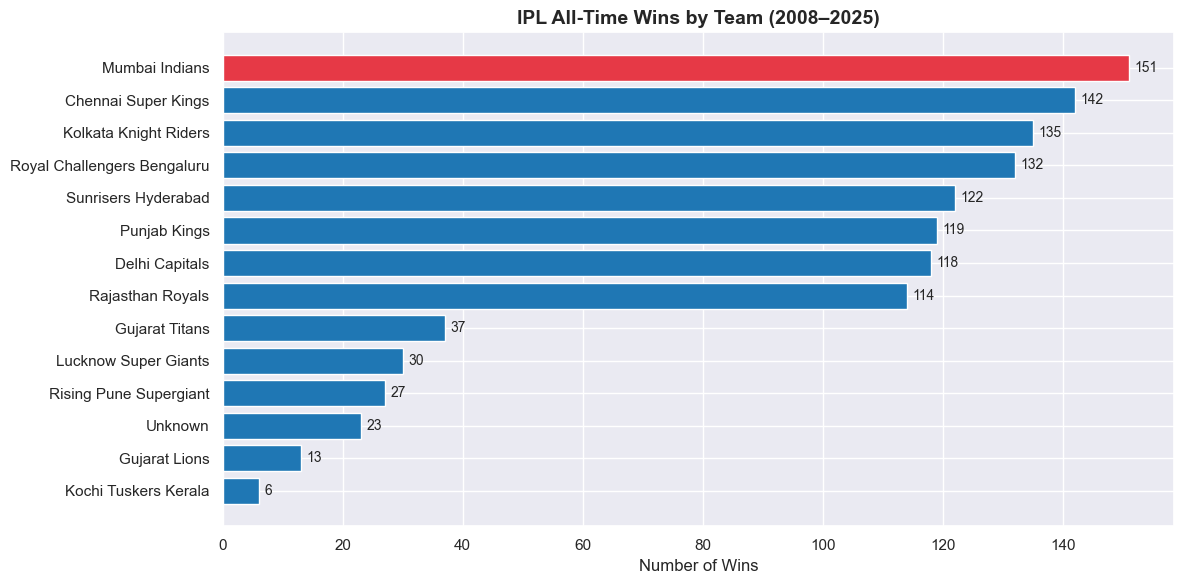

In [73]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#e63946' if i == 0 else '#1f77b4' for i in range(len(q1))]
bars = ax.barh(q1['team'], q1['wins'], color=colors, edgecolor='white')

for bar, val in zip(bars, q1['wins']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)

ax.set_xlabel('Number of Wins')
ax.set_title('IPL All-Time Wins by Team (2008–2025)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('visuals/chart1_team_wins.png', dpi=150)
plt.show()

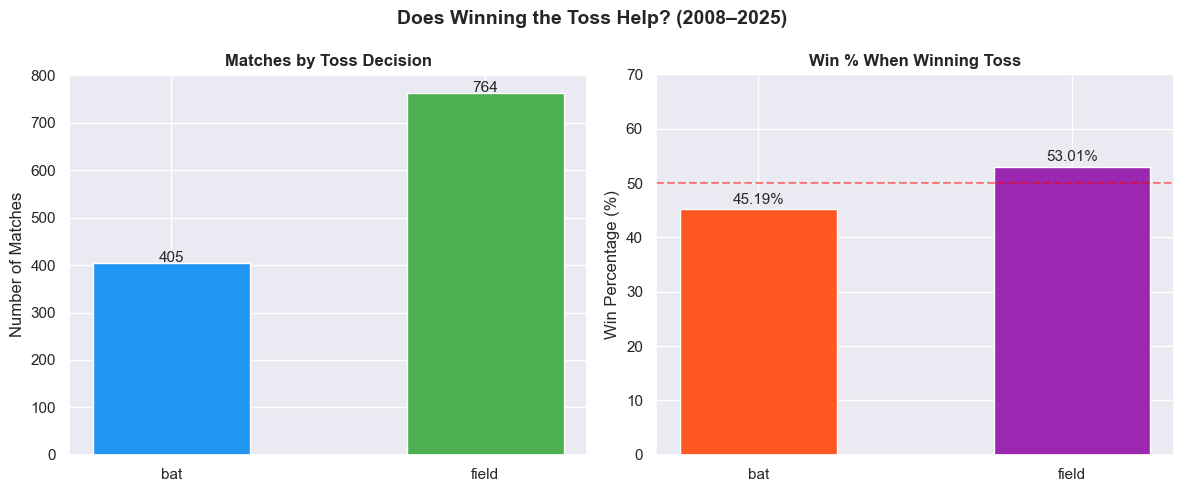

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(q2['toss_decision'], q2['total_matches'],
            color=['#2196F3','#4CAF50'], edgecolor='white', width=0.5)
axes[0].set_title('Matches by Toss Decision', fontweight='bold')
axes[0].set_ylabel('Number of Matches')
for i, v in enumerate(q2['total_matches']):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=11)

axes[1].bar(q2['toss_decision'], q2['win_pct'],
            color=['#FF5722','#9C27B0'], edgecolor='white', width=0.5)
axes[1].set_title('Win % When Winning Toss', fontweight='bold')
axes[1].set_ylabel('Win Percentage (%)')
axes[1].set_ylim(0, 70)
axes[1].axhline(y=50, color='red', linestyle='--', alpha=0.5)
for i, v in enumerate(q2['win_pct']):
    axes[1].text(i, v + 1, f'{v}%', ha='center', fontsize=11)

plt.suptitle('Does Winning the Toss Help? (2008–2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/chart2_toss_impact.png', dpi=150)
plt.show()

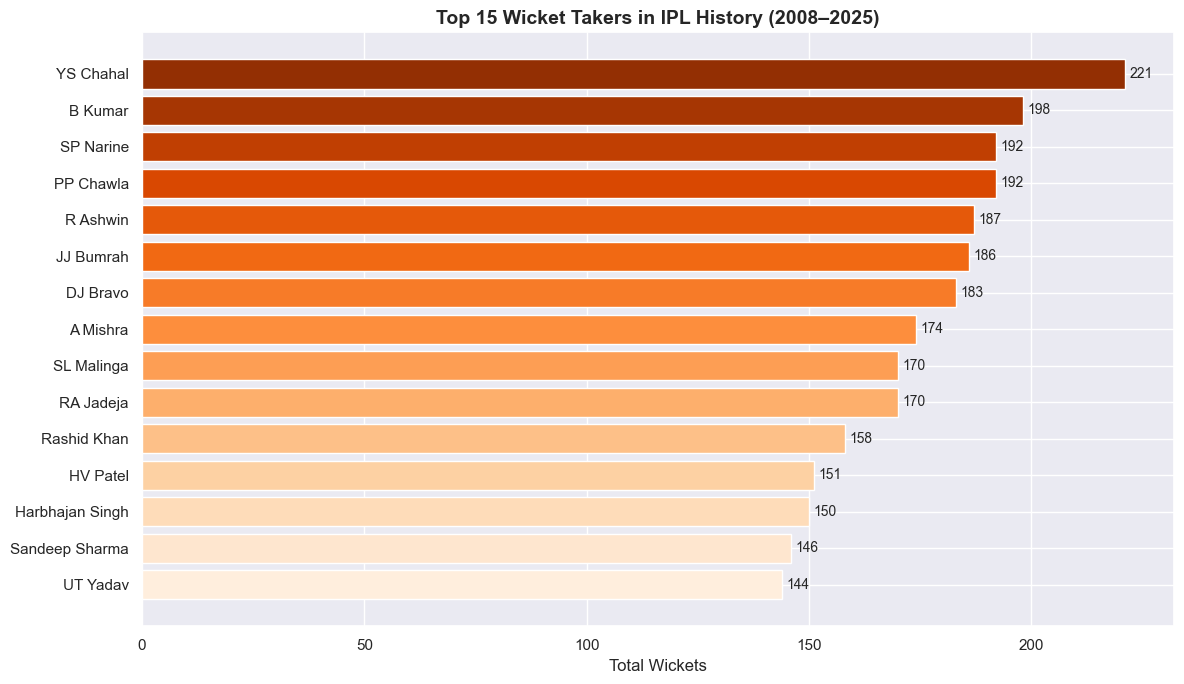

In [75]:
fig, ax = plt.subplots(figsize=(12, 7))

colors = sns.color_palette('Oranges_r', len(q4))
bars = ax.barh(q4['bowler'], q4['wickets'], color=colors, edgecolor='white')

for bar, val in zip(bars, q4['wickets']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)

ax.set_xlabel('Total Wickets')
ax.set_title('Top 15 Wicket Takers in IPL History (2008–2025)',
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('visuals/chart4_top_wickets.png', dpi=150)
plt.show()

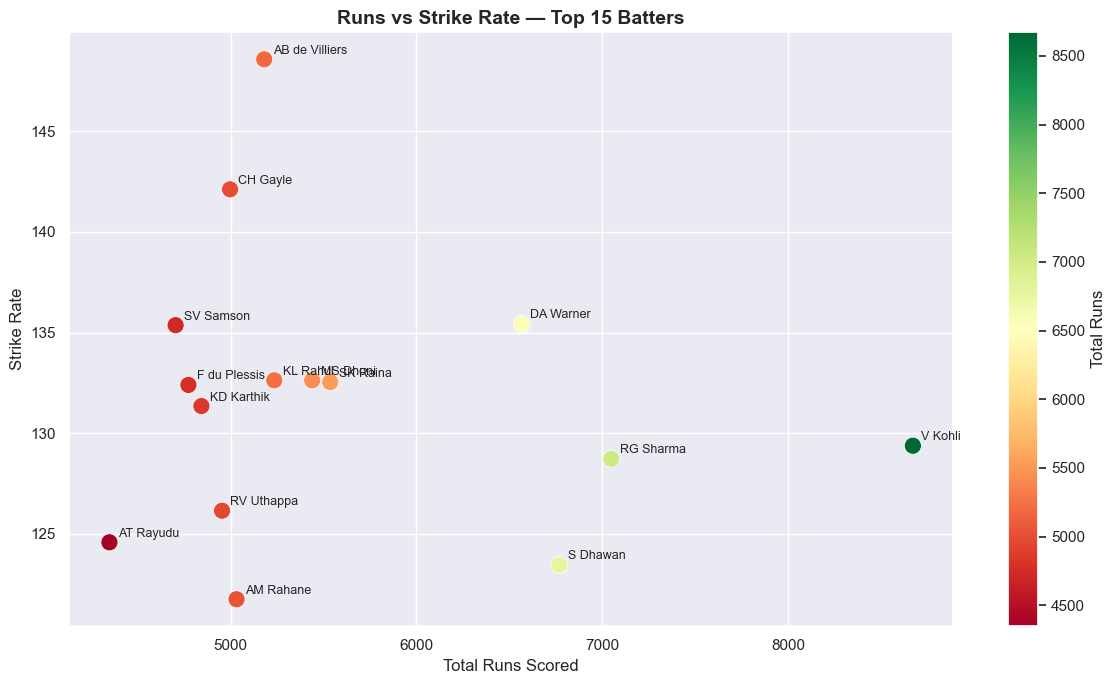

In [76]:
fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(q3['total_runs'], q3['strike_rate'],
                     s=150, c=q3['total_runs'],
                     cmap='RdYlGn', edgecolors='white', linewidth=0.5)

for _, row in q3.iterrows():
    ax.annotate(row['batter'],
                (row['total_runs'], row['strike_rate']),
                textcoords='offset points',
                xytext=(6, 4), fontsize=9)

ax.set_xlabel('Total Runs Scored')
ax.set_ylabel('Strike Rate')
ax.set_title('Runs vs Strike Rate — Top 15 Batters',
             fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Total Runs')
plt.tight_layout()
plt.savefig('visuals/chart5_runs_vs_sr.png', dpi=150)
plt.show()

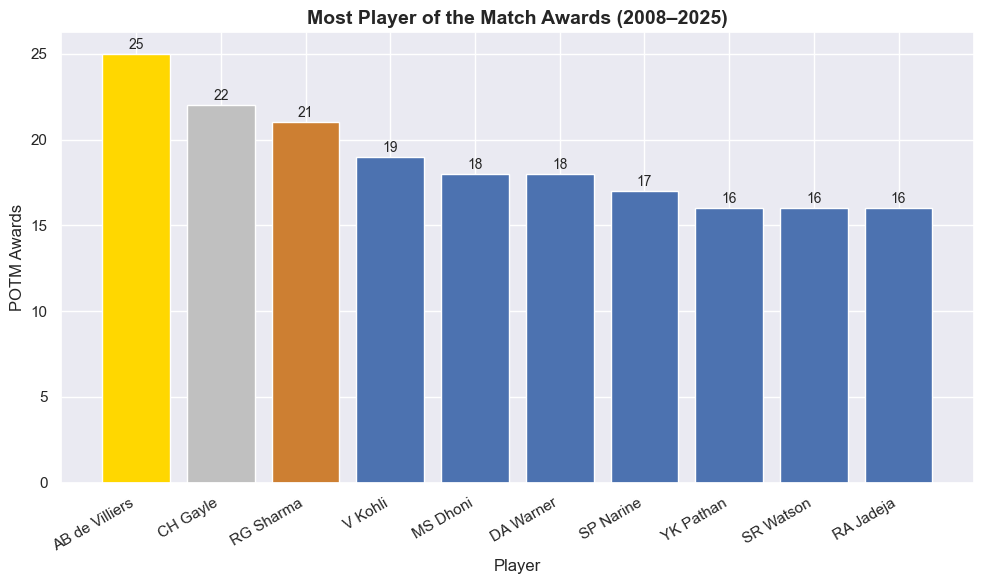

In [77]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['gold' if i == 0 else 'silver' if i == 1
          else '#cd7f32' if i == 2 else '#4C72B0'
          for i in range(len(q6))]

bars = ax.bar(q6['player_of_match'], q6['potm_awards'],
              color=colors, edgecolor='white')

for bar, val in zip(bars, q6['potm_awards']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            str(val), ha='center', fontsize=10)

ax.set_xlabel('Player')
ax.set_ylabel('POTM Awards')
ax.set_title('Most Player of the Match Awards (2008–2025)',
             fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('visuals/chart6_potm.png', dpi=150)
plt.show()

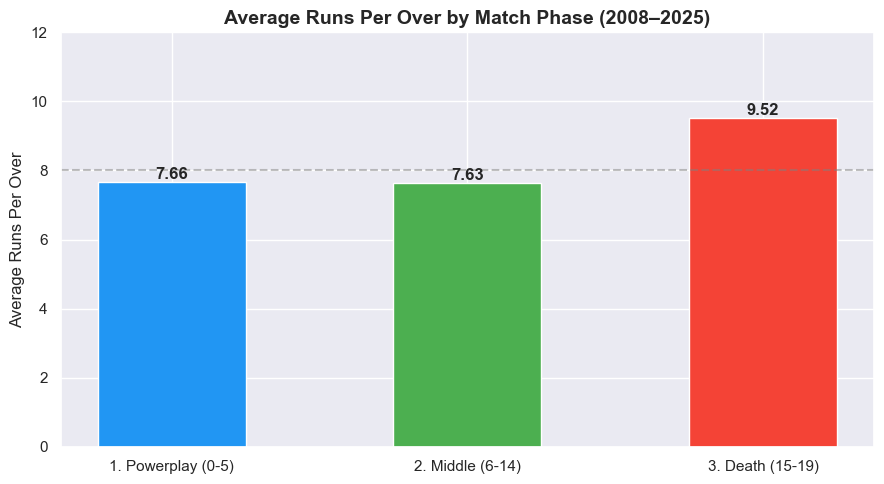

In [78]:
fig, ax = plt.subplots(figsize=(9, 5))

phase_colors = ['#2196F3', '#4CAF50', '#F44336']
bars = ax.bar(q5['phase'], q5['avg_runs_per_over'],
              color=phase_colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, q5['avg_runs_per_over']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{val}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Average Runs Per Over')
ax.set_title('Average Runs Per Over by Match Phase (2008–2025)',
             fontsize=14, fontweight='bold')
ax.set_ylim(0, 12)
ax.axhline(y=8, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('visuals/chart7_runs_per_phase.png', dpi=150)
plt.show()

C:\Users\Prince\AppData\Local\Temp\ipykernel_21660\1575396765.py:30: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Prince\AppData\Local\Temp\ipykernel_21660\1575396765.py:31: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.savefig('visuals/chart8_rcb_2025.png', dpi=150)
c:\Users\Prince\anaconda3\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


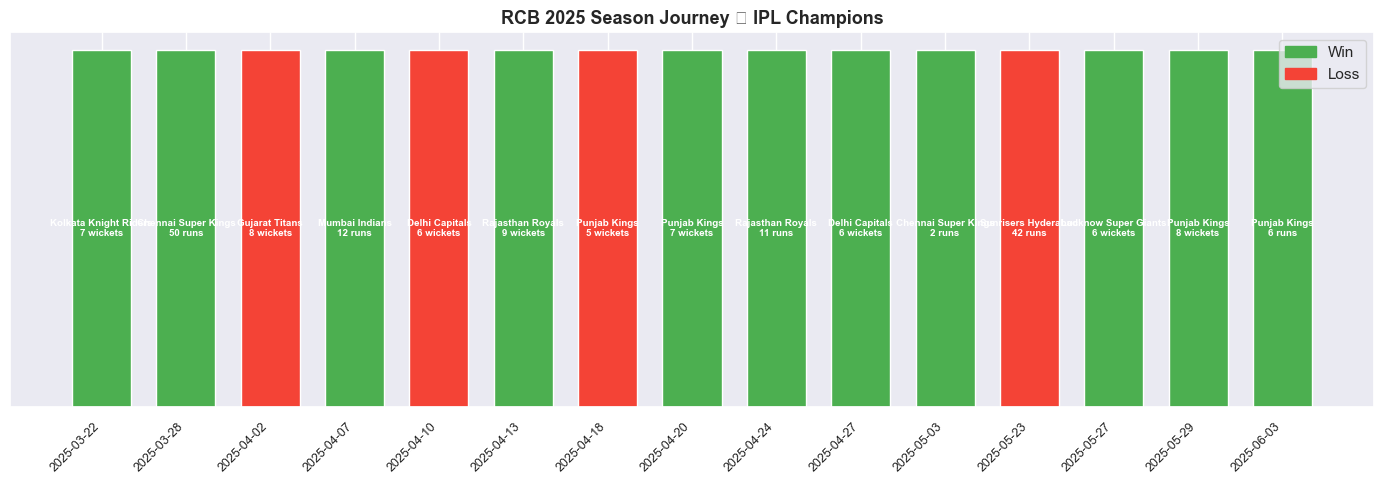

In [79]:
fig, ax = plt.subplots(figsize=(14, 5))

q8['result'] = q8.apply(
    lambda row: 'Win' if row['match_won_by'] == 'Royal Challengers Bengaluru'
    else 'Loss', axis=1)

colors = ['#4CAF50' if r == 'Win' else '#F44336' for r in q8['result']]

ax.bar(range(len(q8)), [1]*len(q8), color=colors, edgecolor='white', width=0.7)

for i, (_, row) in enumerate(q8.iterrows()):
    opponent = row['bowling_team'] if row['batting_team'] == 'Royal Challengers Bengaluru' \
               else row['batting_team']
    ax.text(i, 0.5, f"{opponent}\n{row['win_outcome']}",
            ha='center', va='center', fontsize=7,
            color='white', fontweight='bold')

ax.set_xticks(range(len(q8)))
ax.set_xticklabels([str(d)[:10] for d in q8['date']],
                   rotation=45, ha='right', fontsize=9)
ax.set_yticks([])
ax.set_title('RCB 2025 Season Journey 🏆 IPL Champions',
             fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
legend = [Patch(color='#4CAF50', label='Win'),
          Patch(color='#F44336', label='Loss')]
ax.legend(handles=legend, loc='upper right')

plt.tight_layout()
plt.savefig('visuals/chart8_rcb_2025.png', dpi=150)
plt.show()